# 19) Hourly SW temporal cloud fraction vs GOES spatial cloud fraction

This notebook compares two hourly cloud fractions at Mammoth/CUES:

- **SW temporal fraction:** fraction of all 12 five-minute samples with $k_t < 0.65$.
- **GOES spatial-temporal fraction:** cloud-pixel fraction after applying the Gothic 11d temperature-binned RGB mask to every valid pixel and scan in a 10 km E/W by 5 km southward box. The site's latitude is the box's northern edge.

The expensive pixel processing is external in `build_mammoth_hourly_cloud_fraction.py`; this notebook only loads its yearly outputs and performs residual evaluation.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
ANALYSIS = ROOT if (ROOT / 'output_19_sw_temporal_cf_eval').exists() else ROOT / 'analysis'
OUT = ANALYSIS / 'output_19_sw_temporal_cf_eval'
files = sorted(p for p in OUT.glob('mammoth_cues_hourly_cloud_fraction_20??.csv') if '_test' not in p.stem)
if not files:
    raise FileNotFoundError(f'No completed yearly batch outputs in {OUT.resolve()}')
hourly = pd.concat((pd.read_csv(p, parse_dates=['hour']) for p in files), ignore_index=True)
hourly = hourly.sort_values('hour').drop_duplicates('hour').reset_index(drop=True)
print(f'Loaded {len(hourly):,} GOES hours from {len(files)} yearly files')
display(hourly.head())

Loaded 29,376 GOES hours from 7 yearly files


,hour,goes_cloud_pixels,goes_valid_pixels,goes_n_scans,goes_mean_scan_cloud_fraction,goes_cloud_fraction,sw_cloud_count,sw_n_valid,sw_mean_k_t,sw_cloud_fraction,kt_threshold,residual_goes_minus_sw
0,2019-03-01 00:00:00,1278,1296,12,0.986111,0.986111,6.0,6.0,0.195900,NaN,0.65,NaN
1,2019-03-01 01:00:00,1294,1296,12,0.998457,0.998457,0.0,0.0,0.158497,NaN,0.65,NaN
2,2019-03-01 14:00:00,495,1296,12,0.381944,0.381944,0.0,0.0,0.182969,NaN,0.65,NaN
3,2019-03-01 15:00:00,40,1296,12,0.030864,0.030864,0.0,2.0,0.574242,NaN,0.65,NaN
4,2019-03-01 16:00:00,54,1296,12,0.041667,0.041667,0.0,12.0,0.873515,0.0,0.65,0.041667


## Complete hourly pairs

The primary evaluation requires 12 valid SW samples and 12 GOES scans. This makes each comparison hour represent the intended full temporal sample rather than a varying subset.

In [2]:
compare = hourly.loc[(hourly.sw_n_valid == 12) & (hourly.goes_n_scans == 12)].copy()
compare = compare.dropna(subset=['sw_cloud_fraction', 'goes_cloud_fraction'])
compare['residual'] = compare.goes_cloud_fraction - compare.sw_cloud_fraction
compare['month'] = compare.hour.dt.month
compare['utc_hour'] = compare.hour.dt.hour
print(f'Complete paired hours: {len(compare):,} / {len(hourly):,}')
display(compare.head())

Complete paired hours: 19,200 / 29,376


,hour,goes_cloud_pixels,goes_valid_pixels,goes_n_scans,goes_mean_scan_cloud_fraction,goes_cloud_fraction,sw_cloud_count,sw_n_valid,sw_mean_k_t,sw_cloud_fraction,kt_threshold,residual_goes_minus_sw,residual,month,utc_hour
4,2019-03-01 16:00:00,54,1296,12,0.041667,0.041667,0.0,12.0,0.873515,0.000000,0.65,0.041667,0.041667,3,16
5,2019-03-01 17:00:00,160,1296,12,0.123457,0.123457,0.0,12.0,0.893961,0.000000,0.65,0.123457,0.123457,3,17
6,2019-03-01 18:00:00,1143,1296,12,0.881944,0.881944,0.0,12.0,0.824074,0.000000,0.65,0.881944,0.881944,3,18
7,2019-03-01 19:00:00,1294,1296,12,0.998457,0.998457,1.0,12.0,0.735691,0.083333,0.65,0.915123,0.915123,3,19
8,2019-03-01 20:00:00,1296,1296,12,1.000000,1.000000,12.0,12.0,0.431169,1.000000,0.65,0.000000,0.000000,3,20


## Overall residual statistics

In [3]:
metrics = pd.DataFrame([{'n': len(compare),
    'mean_sw_cloud_fraction': compare.sw_cloud_fraction.mean(),
    'mean_goes_cloud_fraction': compare.goes_cloud_fraction.mean(),
    'bias_goes_minus_sw': compare.residual.mean(),
    'mae': compare.residual.abs().mean(),
    'rmse': np.sqrt(np.mean(compare.residual**2)),
    'correlation': compare[['goes_cloud_fraction','sw_cloud_fraction']].corr().iloc[0,1],
}])
display(metrics.T)

,0
n,19200.000000
mean_sw_cloud_fraction,0.257066
mean_goes_cloud_fraction,0.201028
bias_goes_minus_sw,-0.056038
mae,0.114974
rmse,0.253811
correlation,0.788180


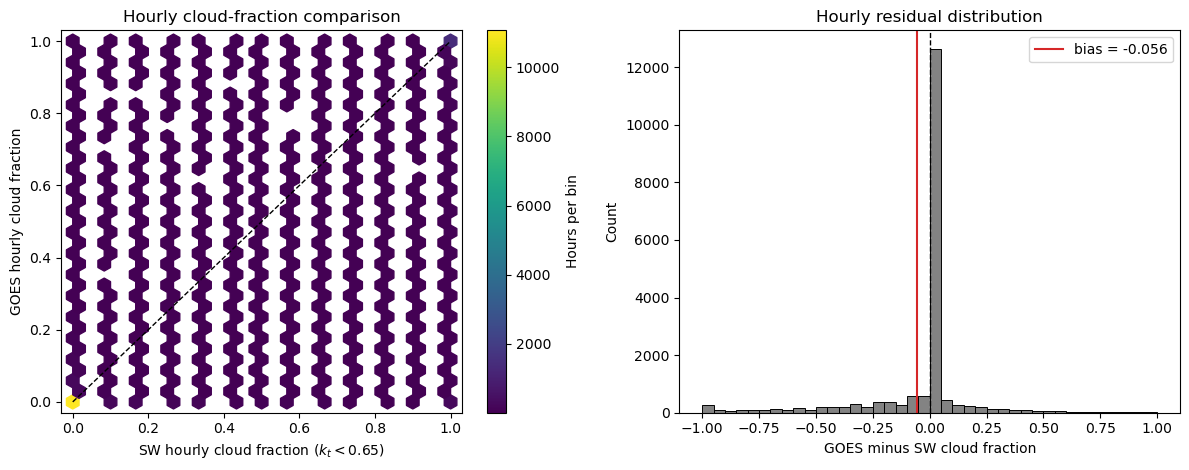

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
hb = axes[0].hexbin(compare.sw_cloud_fraction, compare.goes_cloud_fraction, gridsize=30, mincnt=1, cmap='viridis')
axes[0].plot([0,1], [0,1], 'k--', lw=1)
axes[0].set(xlim=(-.03,1.03), ylim=(-.03,1.03), xlabel=r'SW hourly cloud fraction ($k_t<0.65$)', ylabel='GOES hourly cloud fraction', title='Hourly cloud-fraction comparison')
fig.colorbar(hb, ax=axes[0], label='Hours per bin')
sns.histplot(compare.residual, bins=np.linspace(-1,1,41), ax=axes[1], color='0.35')
axes[1].axvline(0, color='k', ls='--', lw=1)
axes[1].axvline(compare.residual.mean(), color='tab:red', lw=1.5, label=f'bias = {compare.residual.mean():.3f}')
axes[1].set(xlabel='GOES minus SW cloud fraction', title='Hourly residual distribution')
axes[1].legend()
fig.tight_layout()
fig.savefig(OUT/'mammoth_cues_hourly_cloud_fraction_residual_eval.png', dpi=200, bbox_inches='tight')
plt.show()

## Residual structure by month and UTC hour

,month,n,bias,mae,rmse
0,1,1115.0,-0.072166,0.136414,0.281486
1,2,1203.0,-0.045783,0.125189,0.274801
2,3,1543.0,-0.021802,0.150959,0.291238
3,4,1874.0,-0.029895,0.115588,0.240665
4,5,2170.0,-0.012257,0.107628,0.221598
5,6,2309.0,-0.040178,0.107124,0.235989
6,7,1936.0,-0.050226,0.073037,0.190674
7,8,1842.0,-0.047130,0.071516,0.194250
8,9,1557.0,-0.116085,0.138100,0.300812
9,10,1392.0,-0.094951,0.136243,0.298019


,utc_hour,n,bias,mae,rmse
0,0,1078.0,-0.124775,0.150335,0.286692
1,1,149.0,-0.187428,0.201306,0.319777
2,14,140.0,-0.292025,0.300270,0.432809
3,15,1101.0,-0.077842,0.100452,0.235725
4,16,1635.0,-0.063632,0.100174,0.245060
5,17,2253.0,-0.051641,0.100948,0.240734
6,18,2251.0,-0.035106,0.100421,0.235676
7,19,2253.0,-0.021970,0.107812,0.247881
8,20,2254.0,-0.022654,0.107939,0.240706
9,21,2254.0,-0.034023,0.114379,0.247899


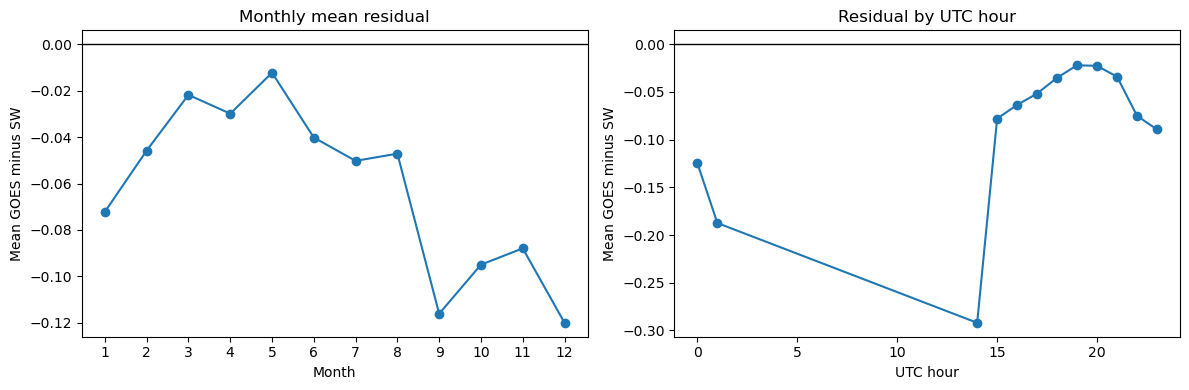

In [5]:
def grouped_metrics(group):
    residual = group.residual
    return pd.Series({'n': len(group), 'bias': residual.mean(), 'mae': residual.abs().mean(), 'rmse': np.sqrt(np.mean(residual**2))})

by_month = compare.groupby('month').apply(grouped_metrics, include_groups=False).reset_index()
by_hour = compare.groupby('utc_hour').apply(grouped_metrics, include_groups=False).reset_index()
display(by_month, by_hour)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].axhline(0, color='k', lw=1); axes[0].plot(by_month.month, by_month.bias, 'o-')
axes[0].set(xlabel='Month', ylabel='Mean GOES minus SW', title='Monthly mean residual', xticks=range(1,13))
axes[1].axhline(0, color='k', lw=1); axes[1].plot(by_hour.utc_hour, by_hour.bias, 'o-')
axes[1].set(xlabel='UTC hour', ylabel='Mean GOES minus SW', title='Residual by UTC hour')
fig.tight_layout(); plt.show()

In [6]:
compare.to_csv(OUT/'mammoth_cues_hourly_cloud_fraction_complete_pairs.csv', index=False)
metrics.to_csv(OUT/'mammoth_cues_hourly_cloud_fraction_metrics.csv', index=False)
by_month.to_csv(OUT/'mammoth_cues_hourly_cloud_fraction_metrics_by_month.csv', index=False)
by_hour.to_csv(OUT/'mammoth_cues_hourly_cloud_fraction_metrics_by_utc_hour.csv', index=False)
print('Saved evaluation outputs to', OUT.resolve())

Saved evaluation outputs to /glade/u/home/cdalden/goes_work/analysis/output_19_sw_temporal_cf_eval


## Seasonal RGB–SW residual distributions (requested 2017–2024)

These panels use every complete hourly RGB/SW pair in the requested 2017–2024 window and do not require an ACM match. Mammoth RGB availability begins in March 2019, so the actual overlap is March 2019–December 2024. Residual is GOES RGB cloud fraction minus the CUES SW-derived cloud fraction.

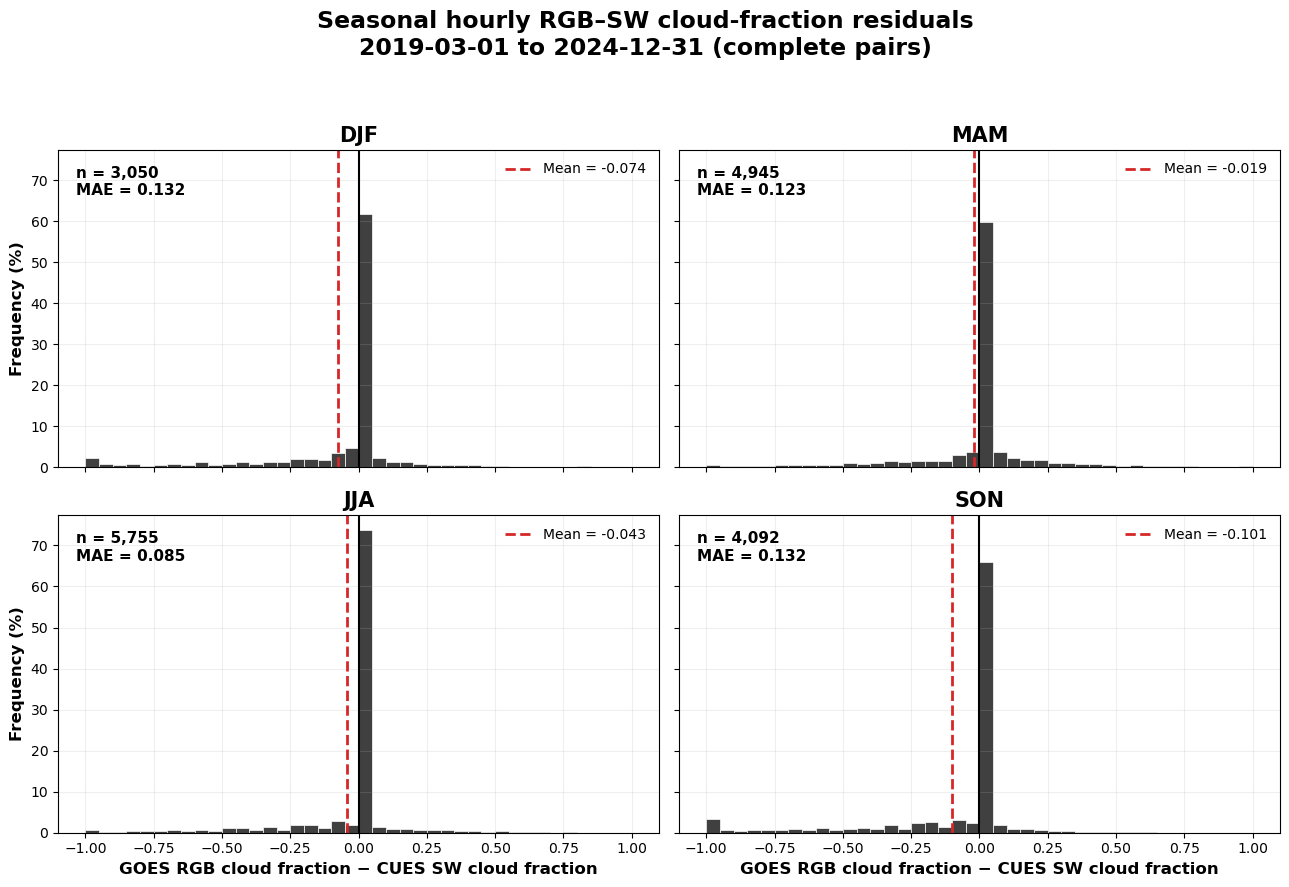

Saved /glade/u/home/cdalden/goes_work/analysis/output_19_sw_temporal_cf_eval/mammoth_rgb_sw_all_timesteps_residual_histograms_by_season_2017_2024.png with 17,842 pairs spanning 2019-03-01 through 2024-12-31.


In [7]:
season_names = {12: 'DJF', 1: 'DJF', 2: 'DJF', 3: 'MAM', 4: 'MAM', 5: 'MAM', 6: 'JJA', 7: 'JJA', 8: 'JJA', 9: 'SON', 10: 'SON', 11: 'SON'}
season_order = ['DJF', 'MAM', 'JJA', 'SON']
season_pairs = compare.loc[(compare['hour'] >= '2017-01-01') & (compare['hour'] < '2025-01-01')].copy()
season_pairs['season'] = season_pairs['hour'].dt.month.map(season_names)
season_pairs.to_csv(OUT/'mammoth_rgb_sw_complete_hourly_pairs_2017_2024.csv', index=False)

bins = np.linspace(-1, 1, 41)
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, season in zip(axes.flat, season_order):
    values = season_pairs.loc[season_pairs['season'] == season, 'residual'].dropna()
    weights = np.full(values.size, 100.0 / values.size) if values.size else None
    ax.hist(values, bins=bins, weights=weights, color='0.25', edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=1.5)
    if values.size:
        ax.axvline(values.mean(), color='#d62728', linewidth=2, linestyle='--', label=f'Mean = {values.mean():.3f}')
    ax.set_title(season, fontsize=15, fontweight='bold')
    ax.text(0.03, 0.95, f'n = {values.size:,}\nMAE = {values.abs().mean():.3f}', transform=ax.transAxes, va='top', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.2)
    ax.legend(loc='upper right', frameon=False)
for ax in axes[-1, :]: ax.set_xlabel('GOES RGB cloud fraction − CUES SW cloud fraction', fontsize=12, fontweight='bold')
for ax in axes[:, 0]: ax.set_ylabel('Frequency (%)', fontsize=12, fontweight='bold')
actual_start = season_pairs['hour'].min().strftime('%Y-%m-%d')
actual_end = season_pairs['hour'].max().strftime('%Y-%m-%d')
fig.suptitle(f'Seasonal hourly RGB–SW cloud-fraction residuals\n{actual_start} to {actual_end} (complete pairs)', fontsize=17, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.94])
season_fig = OUT/'mammoth_rgb_sw_all_timesteps_residual_histograms_by_season_2017_2024.png'
fig.savefig(season_fig, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved {season_fig.resolve()} with {len(season_pairs):,} pairs spanning {actual_start} through {actual_end}.')

## GOES ACM benchmark

ACM uses the native GOES `BCM` field (`0=clear_or_probably_clear`, `1=cloudy_or_probably_cloudy`) over the identical geographic box. The evaluation below is strictly paired: SW, Gothic RGB, and ACM must all have 12 samples/scans in the hour.

In [8]:
acm_files = sorted(OUT.glob('mammoth_acm_hourly_20????.csv'))
if not acm_files:
    raise FileNotFoundError('No completed monthly ACM tables found; wait for the ACM PBS array')
acm = pd.concat((pd.read_csv(p, parse_dates=['hour']) for p in acm_files), ignore_index=True)
acm = acm.sort_values('hour').drop_duplicates('hour')
paired = compare.merge(acm, on='hour', how='inner', validate='one_to_one')
paired = paired.loc[paired.acm_n_scans == 12].dropna(subset=['acm_cloud_fraction']).copy()
paired['rgb_residual'] = paired.goes_cloud_fraction - paired.sw_cloud_fraction
paired['acm_residual'] = paired.acm_cloud_fraction - paired.sw_cloud_fraction
print(f'Complete three-way paired hours: {len(paired):,}')
display(paired.head())

Complete three-way paired hours: 16,779


,hour,goes_cloud_pixels,goes_valid_pixels,goes_n_scans,goes_mean_scan_cloud_fraction,goes_cloud_fraction,sw_cloud_count,sw_n_valid,sw_mean_k_t,sw_cloud_fraction,...,residual,month,utc_hour,acm_cloud_pixels,acm_valid_pixels,acm_n_scans,acm_grid_pixels,acm_cloud_fraction,rgb_residual,acm_residual
0,2019-03-01 16:00:00,54,1296,12,0.041667,0.041667,0.0,12.0,0.873515,0.000000,...,0.041667,3,16,4464,4464,12,372.0,1.0,0.041667,1.000000
1,2019-03-01 17:00:00,160,1296,12,0.123457,0.123457,0.0,12.0,0.893961,0.000000,...,0.123457,3,17,4464,4464,12,372.0,1.0,0.123457,1.000000
2,2019-03-01 18:00:00,1143,1296,12,0.881944,0.881944,0.0,12.0,0.824074,0.000000,...,0.881944,3,18,4464,4464,12,372.0,1.0,0.881944,1.000000
3,2019-03-01 19:00:00,1294,1296,12,0.998457,0.998457,1.0,12.0,0.735691,0.083333,...,0.915123,3,19,4464,4464,12,372.0,1.0,0.915123,0.916667
4,2019-03-01 20:00:00,1296,1296,12,1.000000,1.000000,12.0,12.0,0.431169,1.000000,...,0.000000,3,20,4464,4464,12,372.0,1.0,0.000000,0.000000


In [9]:
def model_metrics(frame, prediction, name):
    residual = frame[prediction] - frame.sw_cloud_fraction
    return {'model': name, 'n': len(frame), 'bias': residual.mean(),
            'mae': residual.abs().mean(), 'rmse': np.sqrt(np.mean(residual**2)),
            'correlation': frame[[prediction, 'sw_cloud_fraction']].corr().iloc[0,1]}

benchmark = pd.DataFrame([
    model_metrics(paired, 'goes_cloud_fraction', 'Gothic RGB mask'),
    model_metrics(paired, 'acm_cloud_fraction', 'GOES ACM'),
])
rgb_mae, acm_mae = benchmark.mae.iloc[0], benchmark.mae.iloc[1]
rgb_rmse, acm_rmse = benchmark.rmse.iloc[0], benchmark.rmse.iloc[1]
improvement = pd.DataFrame([{'RGB MAE improvement vs ACM': acm_mae-rgb_mae,
    'RGB MAE percent improvement': 100*(acm_mae-rgb_mae)/acm_mae,
    'RGB RMSE improvement vs ACM': acm_rmse-rgb_rmse,
    'RGB RMSE percent improvement': 100*(acm_rmse-rgb_rmse)/acm_rmse,
    'RGB lower absolute residual fraction': (paired.rgb_residual.abs() < paired.acm_residual.abs()).mean(),
    'ACM lower absolute residual fraction': (paired.acm_residual.abs() < paired.rgb_residual.abs()).mean(),
    'Equal absolute residual fraction': (paired.acm_residual.abs() == paired.rgb_residual.abs()).mean()}])
display(benchmark, improvement.T)

,model,n,bias,mae,rmse,correlation
0,Gothic RGB mask,16779,-0.055583,0.114113,0.252950,0.787304
1,GOES ACM,16779,0.225277,0.265575,0.416632,0.631215


,0
RGB MAE improvement vs ACM,0.151463
RGB MAE percent improvement,57.031910
RGB RMSE improvement vs ACM,0.163681
RGB RMSE percent improvement,39.286804
RGB lower absolute residual fraction,0.559688
ACM lower absolute residual fraction,0.180106
Equal absolute residual fraction,0.260206


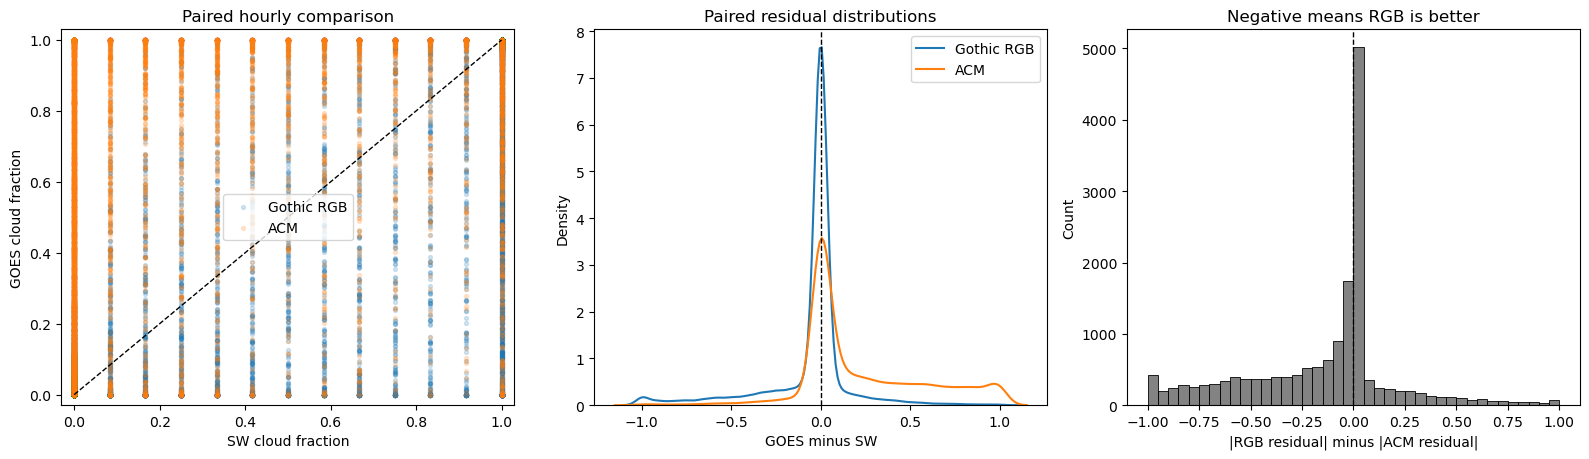

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.7))
for prediction, label, color in [('goes_cloud_fraction','Gothic RGB','tab:blue'), ('acm_cloud_fraction','ACM','tab:orange')]:
    axes[0].scatter(paired.sw_cloud_fraction, paired[prediction], s=8, alpha=.18, label=label, color=color)
axes[0].plot([0,1],[0,1],'k--',lw=1); axes[0].set(xlim=(-.03,1.03),ylim=(-.03,1.03),xlabel='SW cloud fraction',ylabel='GOES cloud fraction',title='Paired hourly comparison'); axes[0].legend()
sns.kdeplot(paired.rgb_residual, ax=axes[1], label='Gothic RGB', color='tab:blue')
sns.kdeplot(paired.acm_residual, ax=axes[1], label='ACM', color='tab:orange')
axes[1].axvline(0,color='k',ls='--',lw=1); axes[1].set(xlabel='GOES minus SW',title='Paired residual distributions'); axes[1].legend()
difference = paired.rgb_residual.abs() - paired.acm_residual.abs()
sns.histplot(difference, bins=np.linspace(-1,1,41), ax=axes[2], color='0.35')
axes[2].axvline(0,color='k',ls='--',lw=1); axes[2].set(xlabel='|RGB residual| minus |ACM residual|',title='Negative means RGB is better')
fig.tight_layout(); fig.savefig(OUT/'mammoth_rgb_vs_acm_paired_residual_eval.png',dpi=200,bbox_inches='tight'); plt.show()

In [11]:
paired.to_csv(OUT/'mammoth_rgb_acm_sw_complete_hourly_pairs.csv', index=False)
benchmark.to_csv(OUT/'mammoth_rgb_vs_acm_paired_metrics.csv', index=False)
improvement.to_csv(OUT/'mammoth_rgb_vs_acm_improvement.csv', index=False)
print('Saved paired RGB-vs-ACM benchmark outputs to', OUT.resolve())

Saved paired RGB-vs-ACM benchmark outputs to /glade/u/home/cdalden/goes_work/analysis/output_19_sw_temporal_cf_eval


## Paired residual histograms by season and UTC hour

Both masks use the same complete three-way paired hours. Histograms use common 0.05-wide bins and show the fraction of observations in each panel, with residual defined as GOES minus SW cloud fraction.

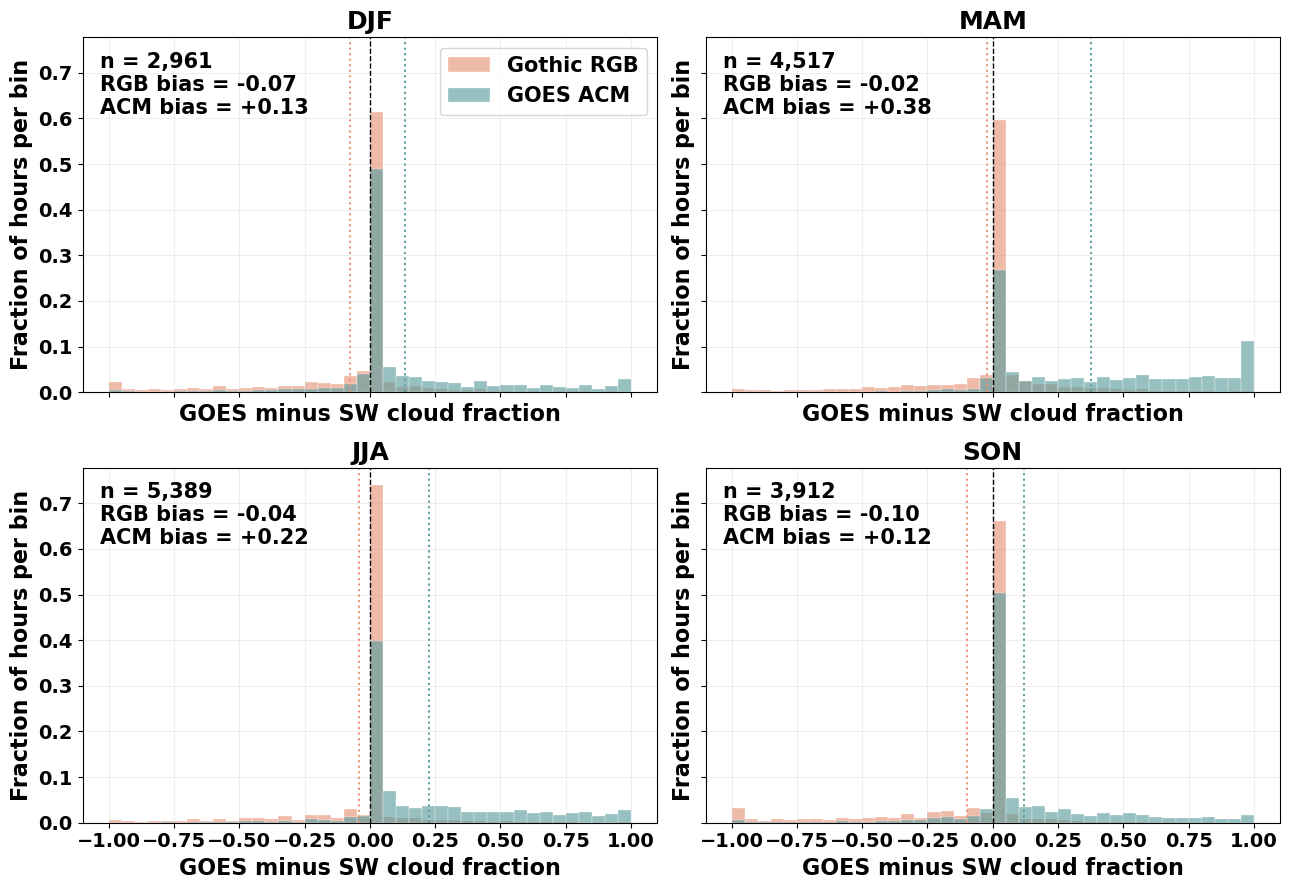

In [12]:
season_for_month = {12:'DJF', 1:'DJF', 2:'DJF', 3:'MAM', 4:'MAM', 5:'MAM', 6:'JJA', 7:'JJA', 8:'JJA', 9:'SON', 10:'SON', 11:'SON'}
paired['season'] = paired.hour.dt.month.map(season_for_month)
residual_bins = np.linspace(-1, 1, 41)
season_order = ['DJF', 'MAM', 'JJA', 'SON']
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, season in zip(axes.ravel(), season_order):
    group = paired.loc[paired.season == season]
    ax.hist(group.rgb_residual, bins=residual_bins, weights=np.ones(len(group))/len(group), histtype='bar', alpha=.65, color='darksalmon', edgecolor='white', lw=.35, label='Gothic RGB')
    ax.hist(group.acm_residual, bins=residual_bins, weights=np.ones(len(group))/len(group), histtype='bar', alpha=.65, color='cadetblue', edgecolor='white', lw=.35, label='GOES ACM')
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.axvline(group.rgb_residual.mean(), color='darksalmon', ls=':', lw=1.5)
    ax.axvline(group.acm_residual.mean(), color='cadetblue', ls=':', lw=1.5)
    ax.set_title(season, fontsize=18, fontweight='bold')
    ax.text(.03, .96, f'n = {len(group):,}\nRGB bias = {group.rgb_residual.mean():+.2f}\nACM bias = {group.acm_residual.mean():+.2f}', transform=ax.transAxes, va='top', fontsize=15, fontweight='bold')
    ax.set_xlabel('GOES minus SW cloud fraction', fontsize=16, fontweight='bold'); ax.set_ylabel('Fraction of hours per bin', fontsize=16, fontweight='bold'); ax.grid(alpha=.2)
    ax.tick_params(axis='both', labelsize=14)
    for tick_label in [*ax.get_xticklabels(), *ax.get_yticklabels()]: tick_label.set_fontweight('bold')
axes[0,0].legend(prop={'size': 15, 'weight': 'bold'})
fig.tight_layout(); fig.savefig(OUT/'mammoth_rgb_acm_residual_histograms_by_season.png', dpi=200, bbox_inches='tight'); plt.show()

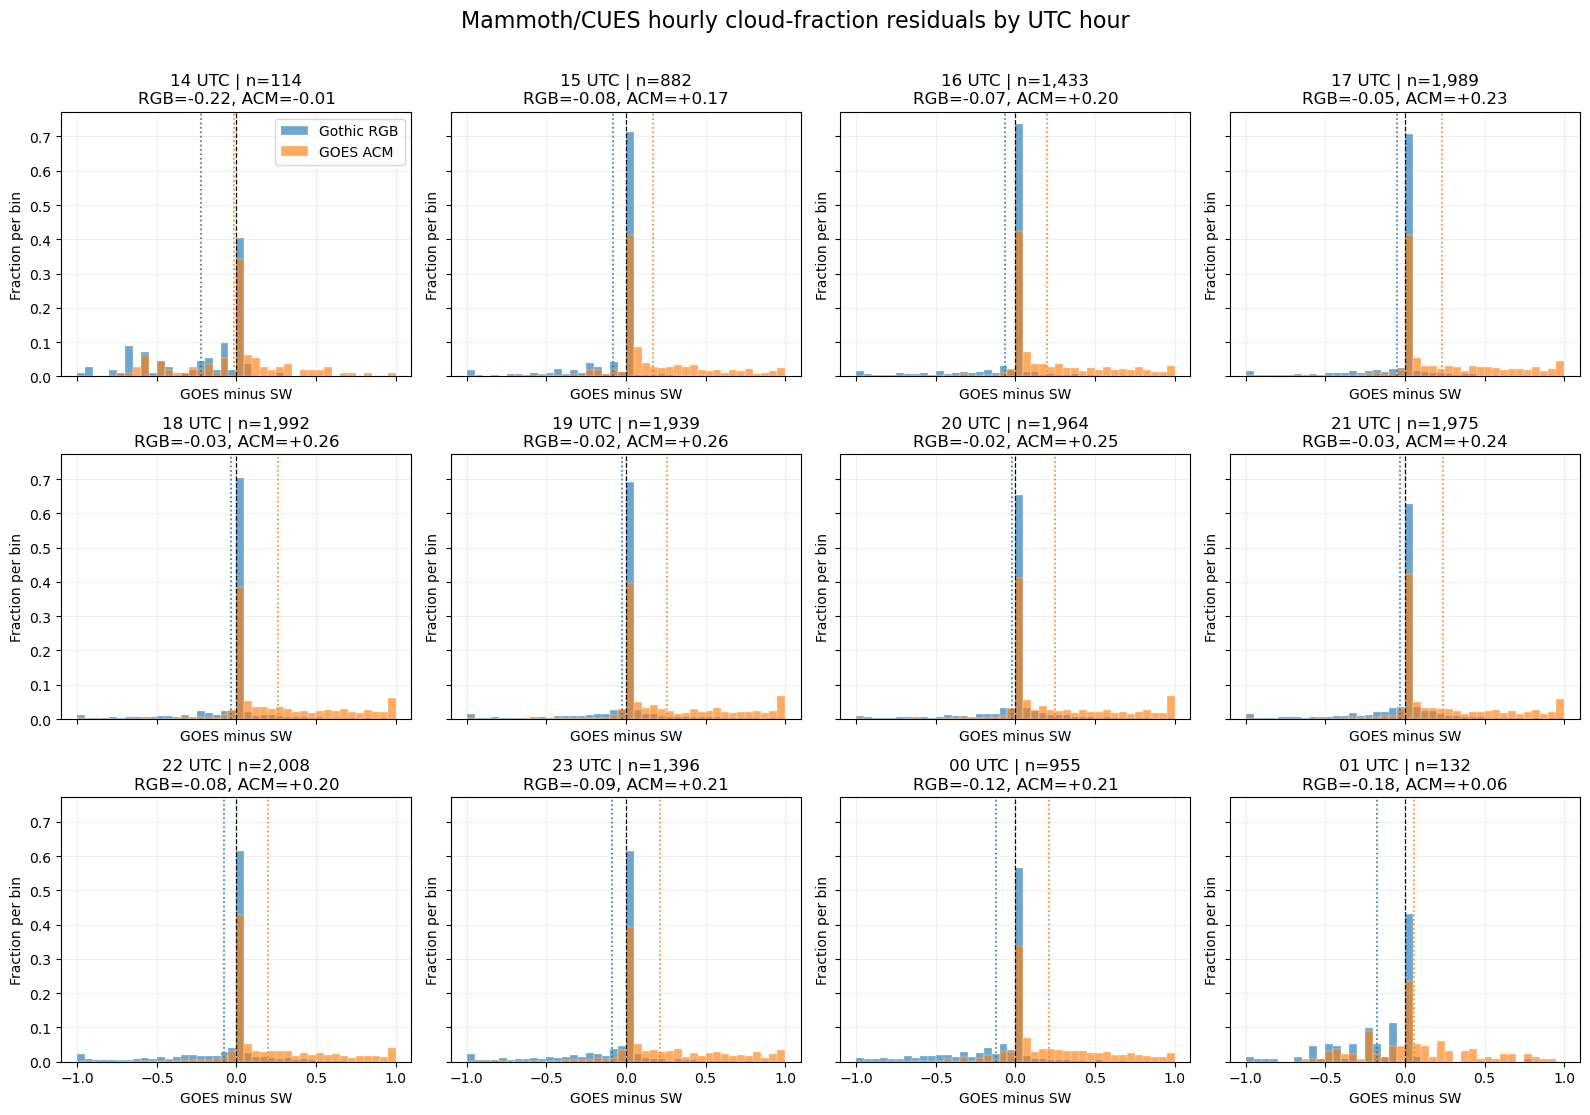

In [13]:
paired['utc_hour'] = paired.hour.dt.hour
hour_order = [14,15,16,17,18,19,20,21,22,23,0,1]
fig, axes = plt.subplots(3, 4, figsize=(16, 11), sharex=True, sharey=True)
for ax, utc_hour in zip(axes.ravel(), hour_order):
    group = paired.loc[paired.utc_hour == utc_hour]
    if group.empty:
        ax.set_visible(False); continue
    ax.hist(group.rgb_residual, bins=residual_bins, weights=np.ones(len(group))/len(group), histtype='bar', alpha=.65, color='tab:blue', edgecolor='white', lw=.3, label='Gothic RGB')
    ax.hist(group.acm_residual, bins=residual_bins, weights=np.ones(len(group))/len(group), histtype='bar', alpha=.65, color='tab:orange', edgecolor='white', lw=.3, label='GOES ACM')
    ax.axvline(0, color='k', ls='--', lw=.9)
    ax.axvline(group.rgb_residual.mean(), color='tab:blue', ls=':', lw=1.2)
    ax.axvline(group.acm_residual.mean(), color='tab:orange', ls=':', lw=1.2)
    ax.set_title(f'{utc_hour:02d} UTC | n={len(group):,}\nRGB={group.rgb_residual.mean():+.2f}, ACM={group.acm_residual.mean():+.2f}')
    ax.set_xlabel('GOES minus SW'); ax.set_ylabel('Fraction per bin'); ax.grid(alpha=.2)
axes[0,0].legend()
fig.suptitle('Mammoth/CUES hourly cloud-fraction residuals by UTC hour', fontsize=16, y=1.01)
fig.tight_layout(); fig.savefig(OUT/'mammoth_rgb_acm_residual_histograms_by_utc_hour.png', dpi=200, bbox_inches='tight'); plt.show()

## Separate residual figures for each GOES mask

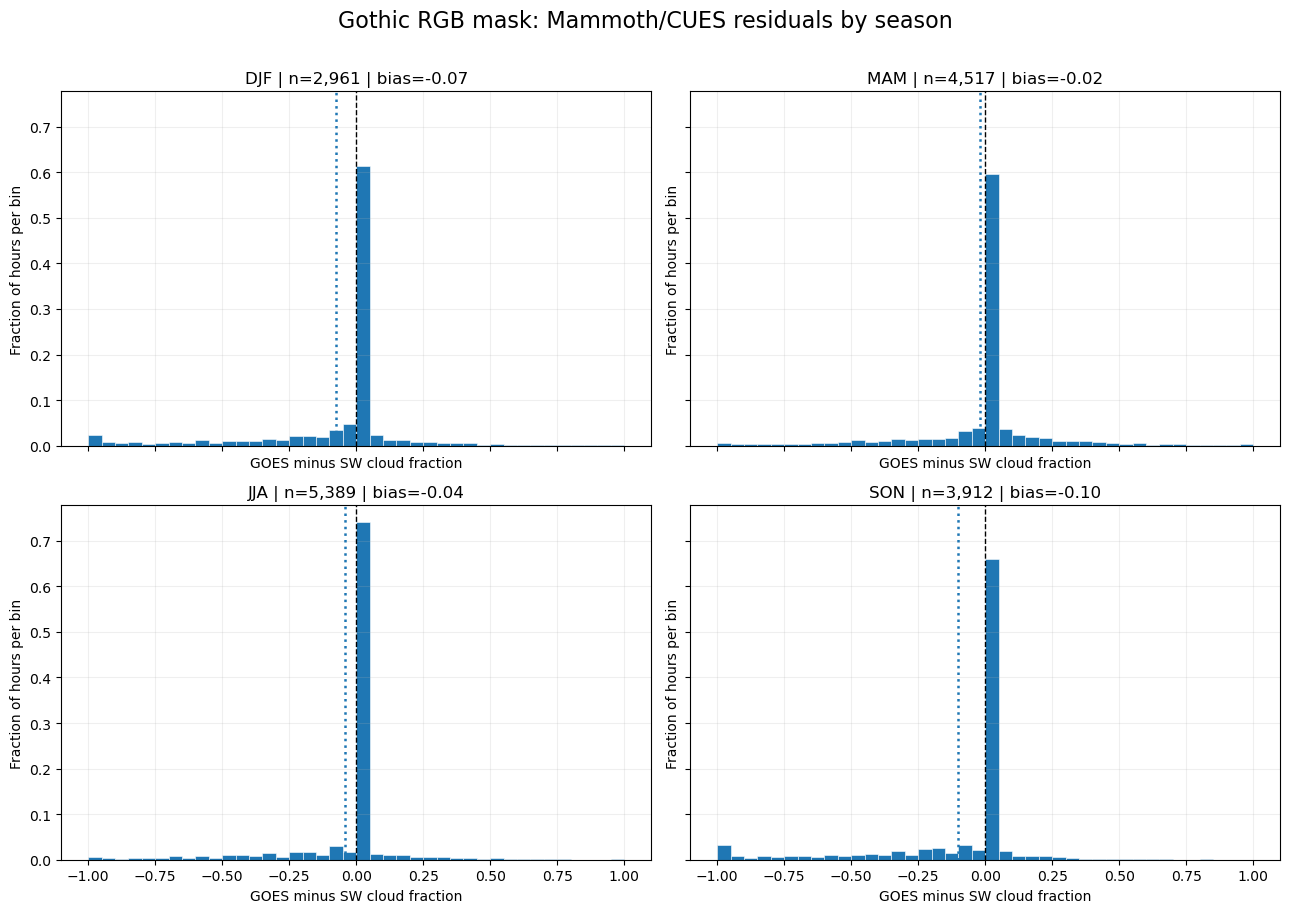

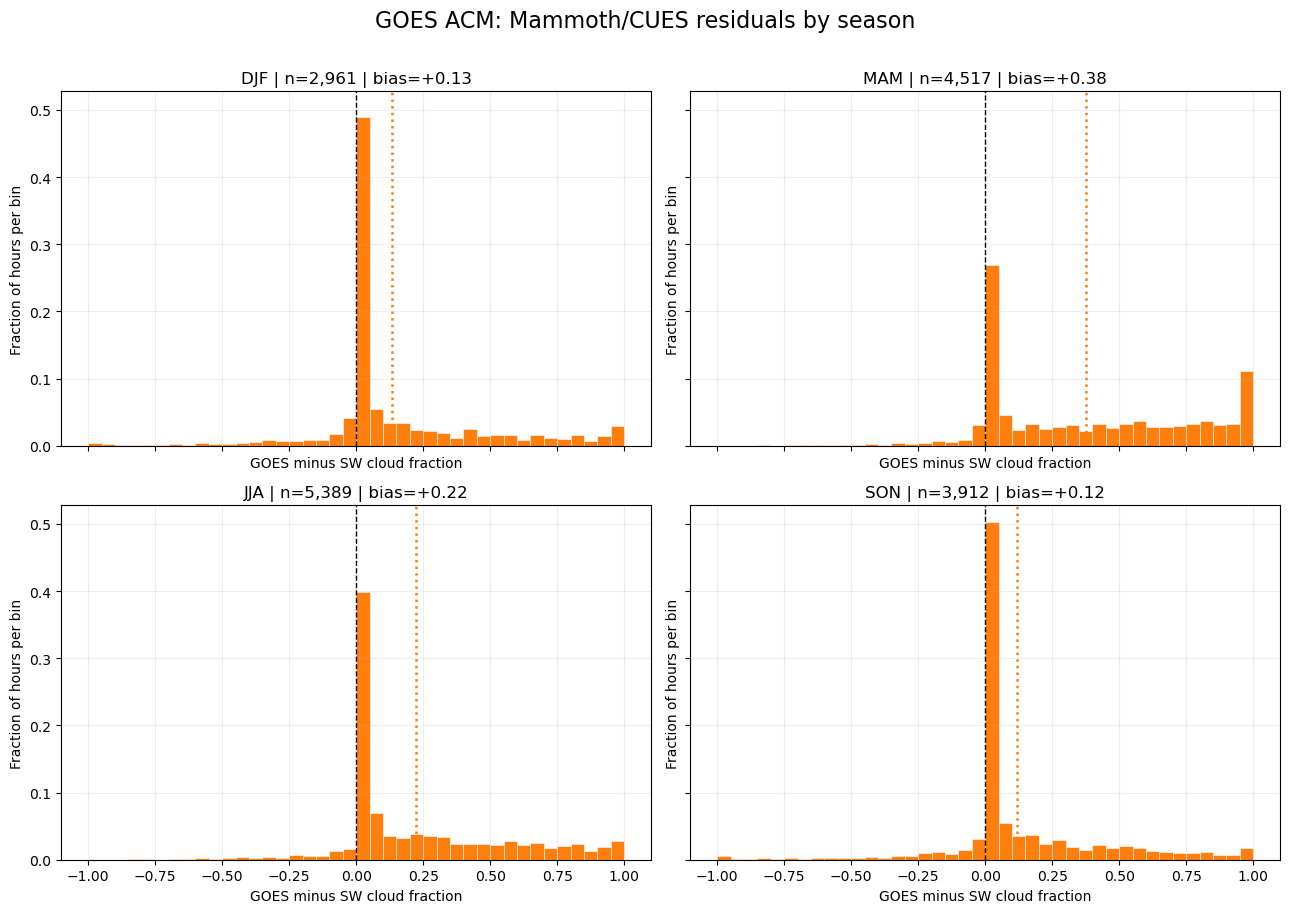

In [14]:
mask_styles = [('rgb_residual', 'Gothic RGB mask', 'tab:blue', 'rgb'), ('acm_residual', 'GOES ACM', 'tab:orange', 'acm')]
for residual_col, model_label, color, file_token in mask_styles:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
    for ax, season in zip(axes.ravel(), season_order):
        group = paired.loc[paired.season == season]
        residual = group[residual_col]
        ax.hist(residual, bins=residual_bins, weights=np.ones(len(group))/len(group), color=color, edgecolor='white', lw=.4)
        ax.axvline(0, color='k', ls='--', lw=1)
        ax.axvline(residual.mean(), color=color, ls=':', lw=1.8)
        ax.set_title(f'{season} | n={len(group):,} | bias={residual.mean():+.2f}')
        ax.set_xlabel('GOES minus SW cloud fraction'); ax.set_ylabel('Fraction of hours per bin'); ax.grid(alpha=.2)
    fig.suptitle(f'{model_label}: Mammoth/CUES residuals by season', fontsize=16, y=1.01)
    fig.tight_layout(); fig.savefig(OUT/f'mammoth_{file_token}_residual_histograms_by_season.png', dpi=200, bbox_inches='tight'); plt.show()

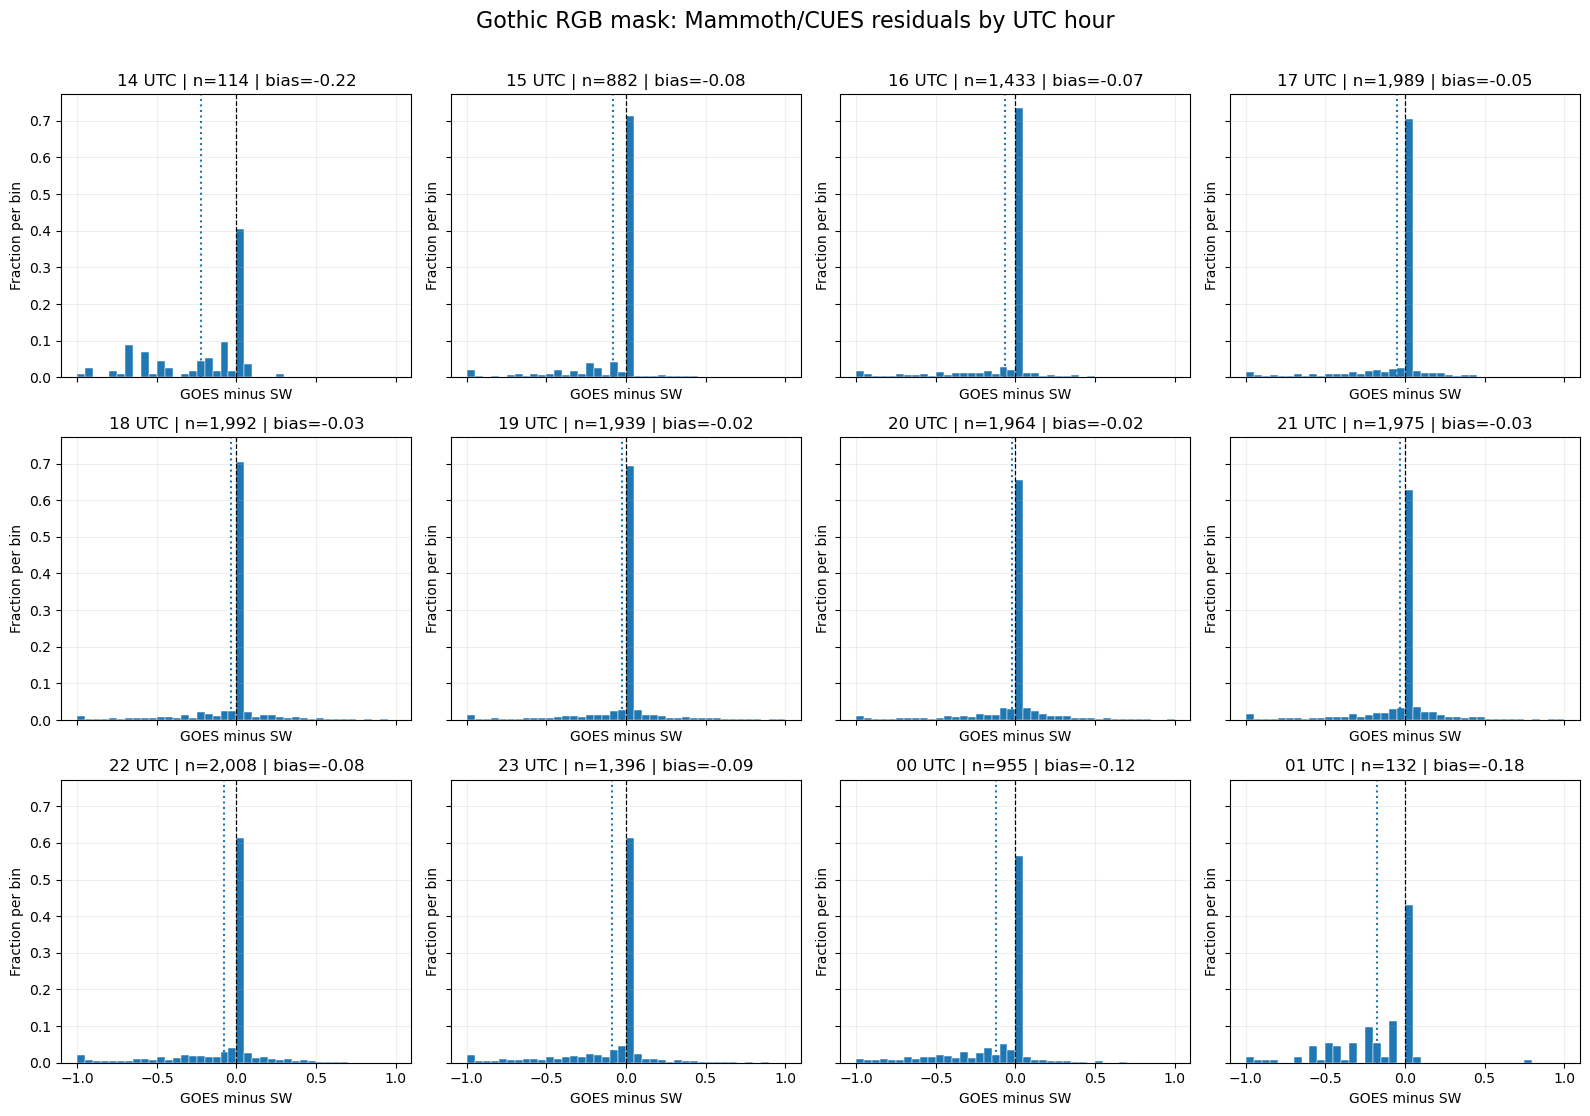

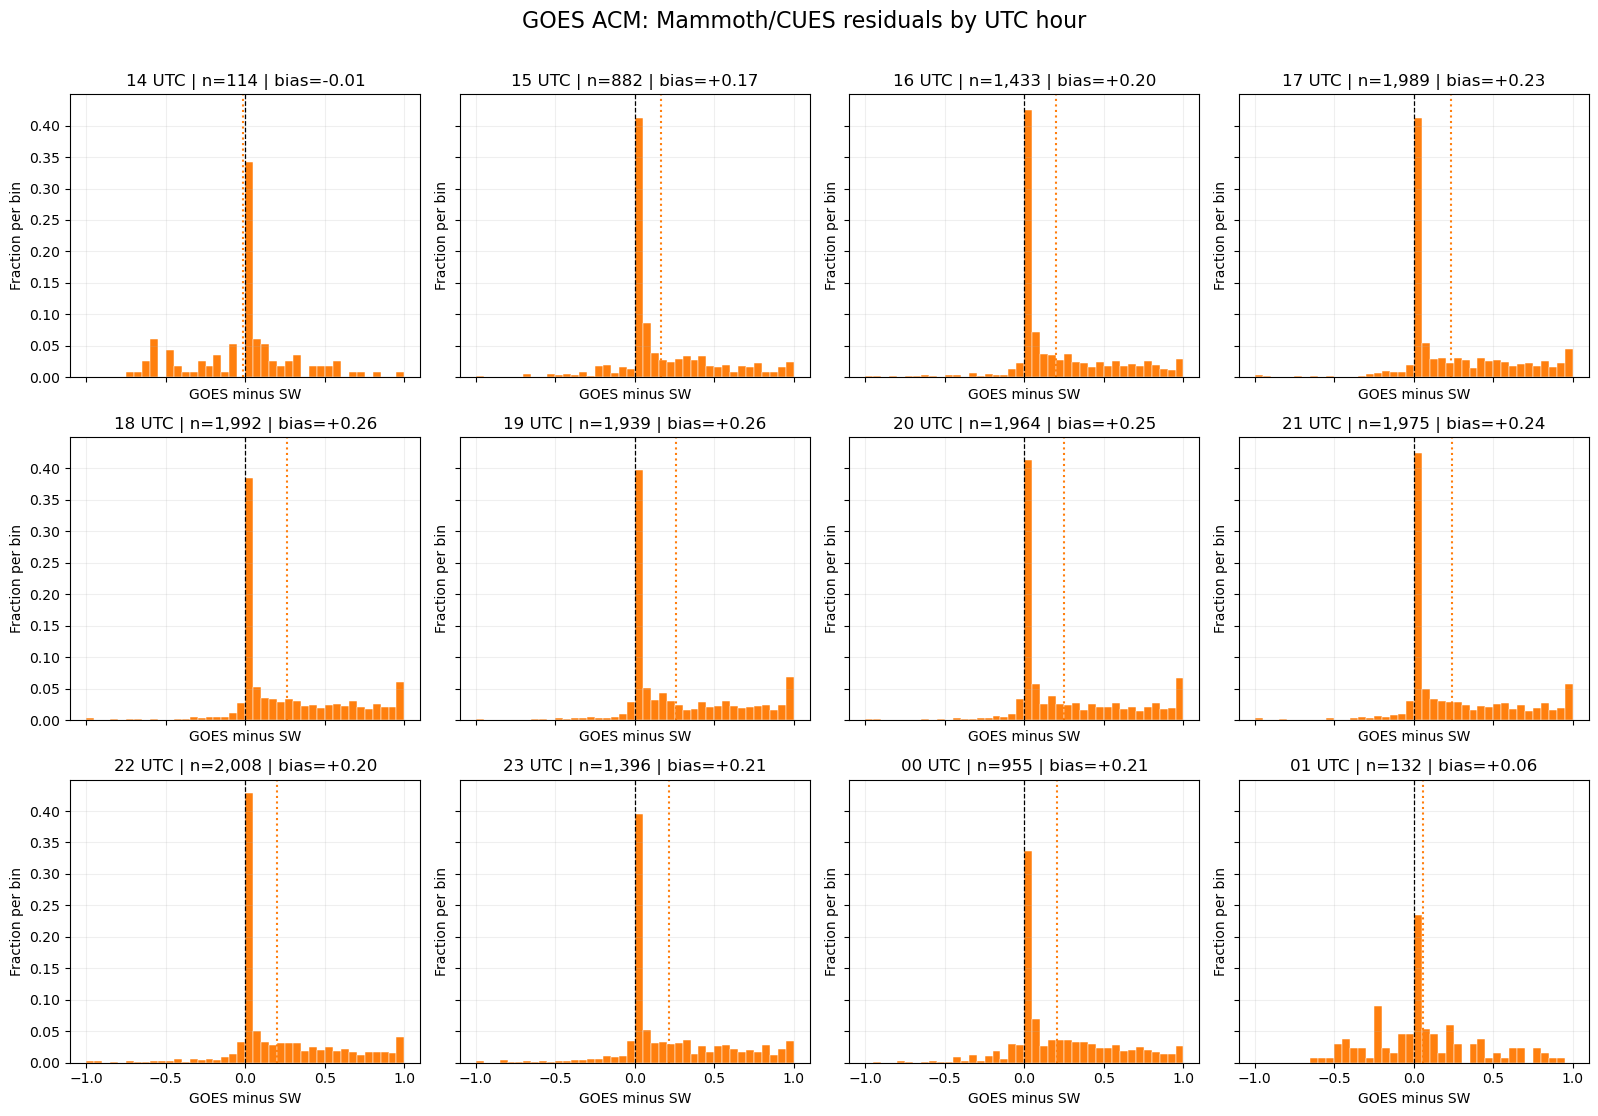

In [15]:
for residual_col, model_label, color, file_token in mask_styles:
    fig, axes = plt.subplots(3, 4, figsize=(16, 11), sharex=True, sharey=True)
    for ax, utc_hour in zip(axes.ravel(), hour_order):
        group = paired.loc[paired.utc_hour == utc_hour]
        if group.empty:
            ax.set_visible(False); continue
        residual = group[residual_col]
        ax.hist(residual, bins=residual_bins, weights=np.ones(len(group))/len(group), color=color, edgecolor='white', lw=.35)
        ax.axvline(0, color='k', ls='--', lw=.9)
        ax.axvline(residual.mean(), color=color, ls=':', lw=1.5)
        ax.set_title(f'{utc_hour:02d} UTC | n={len(group):,} | bias={residual.mean():+.2f}')
        ax.set_xlabel('GOES minus SW'); ax.set_ylabel('Fraction per bin'); ax.grid(alpha=.2)
    fig.suptitle(f'{model_label}: Mammoth/CUES residuals by UTC hour', fontsize=16, y=1.01)
    fig.tight_layout(); fig.savefig(OUT/f'mammoth_{file_token}_residual_histograms_by_utc_hour.png', dpi=200, bbox_inches='tight'); plt.show()

## Seasonal RGB vs ACM residuals when observed SW cloud fraction is nonzero

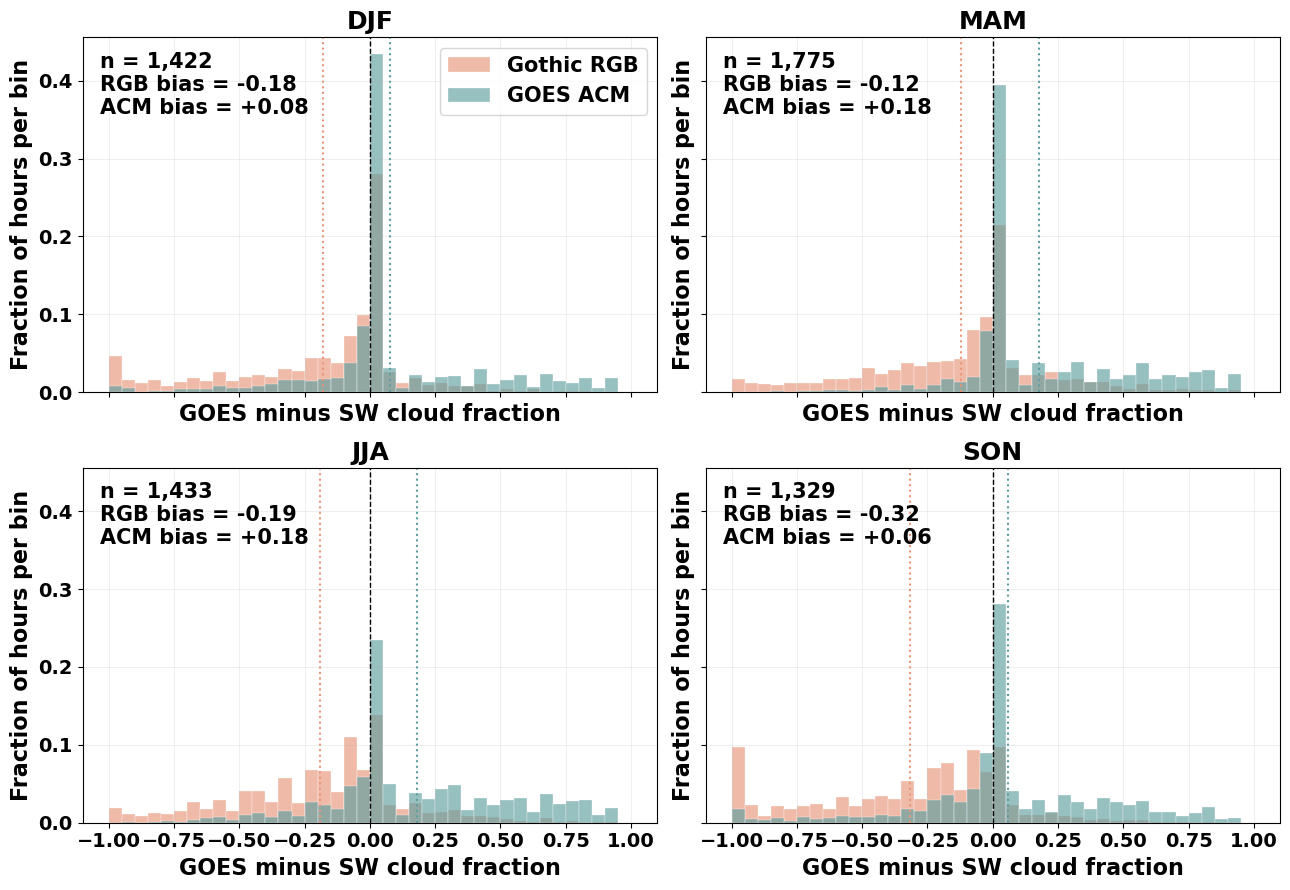

In [16]:
paired_nonzero_sw = paired.loc[paired.sw_cloud_fraction != 0].copy()
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, season in zip(axes.ravel(), season_order):
    group = paired_nonzero_sw.loc[paired_nonzero_sw.season == season]
    ax.hist(group.rgb_residual, bins=residual_bins, weights=np.ones(len(group))/len(group), histtype='bar', alpha=.65, color='darksalmon', edgecolor='white', lw=.35, label='Gothic RGB')
    ax.hist(group.acm_residual, bins=residual_bins, weights=np.ones(len(group))/len(group), histtype='bar', alpha=.65, color='cadetblue', edgecolor='white', lw=.35, label='GOES ACM')
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.axvline(group.rgb_residual.mean(), color='darksalmon', ls=':', lw=1.5)
    ax.axvline(group.acm_residual.mean(), color='cadetblue', ls=':', lw=1.5)
    ax.set_title(season, fontsize=18, fontweight='bold')
    ax.text(.03, .96, f'n = {len(group):,}\nRGB bias = {group.rgb_residual.mean():+.2f}\nACM bias = {group.acm_residual.mean():+.2f}', transform=ax.transAxes, va='top', fontsize=15, fontweight='bold')
    ax.set_xlabel('GOES minus SW cloud fraction', fontsize=16, fontweight='bold'); ax.set_ylabel('Fraction of hours per bin', fontsize=16, fontweight='bold'); ax.grid(alpha=.2)
    ax.tick_params(axis='both', labelsize=14)
    for tick_label in [*ax.get_xticklabels(), *ax.get_yticklabels()]: tick_label.set_fontweight('bold')
axes[0,0].legend(prop={'size': 15, 'weight': 'bold'})
fig.tight_layout(); fig.savefig(OUT/'mammoth_rgb_acm_residual_histograms_by_season_nonzero_sw.png', dpi=200, bbox_inches='tight'); plt.show()